In [171]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Read file
df = pd.read_csv('hotel_bookings.csv')

# create backup from the data.
data_backup = df.copy()


In [172]:
# Quick inspection

print('Dataset shape:', data_backup.shape)
print('Dataset columns:', data_backup.columns.to_list())
print('\nFirst few rows: ')

data_backup.head(10)
data_backup.describe()
data_backup.info()


Dataset shape: (119390, 32)
Dataset columns: ['hotel', 'is_canceled', 'lead_time', 'arrival_date_year', 'arrival_date_month', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'meal', 'country', 'market_segment', 'distribution_channel', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'reserved_room_type', 'assigned_room_type', 'booking_changes', 'deposit_type', 'agent', 'company', 'days_in_waiting_list', 'customer_type', 'adr', 'required_car_parking_spaces', 'total_of_special_requests', 'reservation_status', 'reservation_status_date']

First few rows: 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled     

In [173]:
# check for missing values 

print('\n Missing values per column: ')
missing_data = data_backup.isnull().sum()
missing_data


 Missing values per column: 


hotel                                  0
is_canceled                            0
lead_time                              0
arrival_date_year                      0
arrival_date_month                     0
arrival_date_week_number               0
arrival_date_day_of_month              0
stays_in_weekend_nights                0
stays_in_week_nights                   0
adults                                 0
children                               4
babies                                 0
meal                                   0
country                              488
market_segment                         0
distribution_channel                   0
is_repeated_guest                      0
previous_cancellations                 0
previous_bookings_not_canceled         0
reserved_room_type                     0
assigned_room_type                     0
booking_changes                        0
deposit_type                           0
agent                              16340
company         

In [174]:
data_backup

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.00,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.00,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.00,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.00,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.00,0,1,Check-Out,2015-07-03
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119385,City Hotel,0,23,2017,August,35,30,2,5,2,...,No Deposit,394.0,NaN,0,Transient,96.14,0,0,Check-Out,2017-09-06
119386,City Hotel,0,102,2017,August,35,31,2,5,3,...,No Deposit,9.0,NaN,0,Transient,225.43,0,2,Check-Out,2017-09-07
119387,City Hotel,0,34,2017,August,35,31,2,5,2,...,No Deposit,9.0,NaN,0,Transient,157.71,0,4,Check-Out,2017-09-07
119388,City Hotel,0,109,2017,August,35,31,2,5,2,...,No Deposit,89.0,NaN,0,Transient,104.40,0,0,Check-Out,2017-09-07


Headline: Part 2: From Gaps to Insights 🛠️🏨

"I promised action, not just talk. Today I moved from the 'Audit' to the 'Cleaning' phase of my Hospitality project.

Why I chose these specific methods:

The 'Direct' Flag: By filling agent and company nulls with 0, I’ve created a numerical feature the ML model can use to identify Direct Bookings—the highest margin segment in any hotel.

The Global Context: For the 488 missing countries, I used the 'Mode'. In hospitality, your primary market usually remains consistent; using the most frequent value maintains the statistical integrity of the guest profile.

ML Readiness: Machine Learning models don't speak 'NULL'. By standardizing these values now, I’m building a clean pipeline for the price forecasting model.

In [175]:
# Part 2 

# Handle missing Date.

# first the country 
data_backup['country'] = data_backup['country'].fillna(df['country'].mode()[0])

# second the agent

data_backup['agent'] = data_backup['agent'].fillna(0)

# Third the agent

data_backup['company'] = data_backup['company'].fillna(0)

# Fourth the children

data_backup['children'] = data_backup['children'].fillna(df['children'].mode()[0])


data_backup.isnull().sum()

hotel                             0
is_canceled                       0
lead_time                         0
arrival_date_year                 0
arrival_date_month                0
arrival_date_week_number          0
arrival_date_day_of_month         0
stays_in_weekend_nights           0
stays_in_week_nights              0
adults                            0
children                          0
babies                            0
meal                              0
country                           0
market_segment                    0
distribution_channel              0
is_repeated_guest                 0
previous_cancellations            0
previous_bookings_not_canceled    0
reserved_room_type                0
assigned_room_type                0
booking_changes                   0
deposit_type                      0
agent                             0
company                           0
days_in_waiting_list              0
customer_type                     0
adr                         

In [176]:
data_backup

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,0.0,0.0,0,Transient,0.00,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,0.0,0.0,0,Transient,0.00,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,0.0,0.0,0,Transient,75.00,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,0.0,0,Transient,75.00,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,0.0,0,Transient,98.00,0,1,Check-Out,2015-07-03
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119385,City Hotel,0,23,2017,August,35,30,2,5,2,...,No Deposit,394.0,0.0,0,Transient,96.14,0,0,Check-Out,2017-09-06
119386,City Hotel,0,102,2017,August,35,31,2,5,3,...,No Deposit,9.0,0.0,0,Transient,225.43,0,2,Check-Out,2017-09-07
119387,City Hotel,0,34,2017,August,35,31,2,5,2,...,No Deposit,9.0,0.0,0,Transient,157.71,0,4,Check-Out,2017-09-07
119388,City Hotel,0,109,2017,August,35,31,2,5,2,...,No Deposit,89.0,0.0,0,Transient,104.40,0,0,Check-Out,2017-09-07


--- Benchmark Metrics (Paying Guests Only) ---
City Hotel Avg ADR:   $106.93
Resort Hotel Avg ADR: $96.77



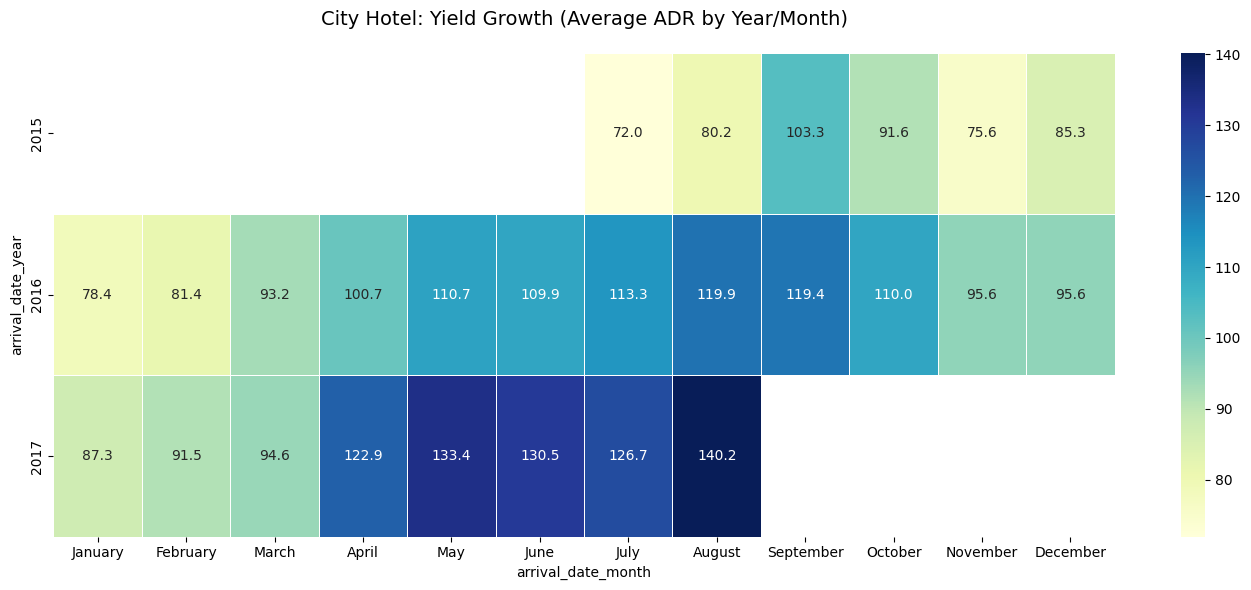

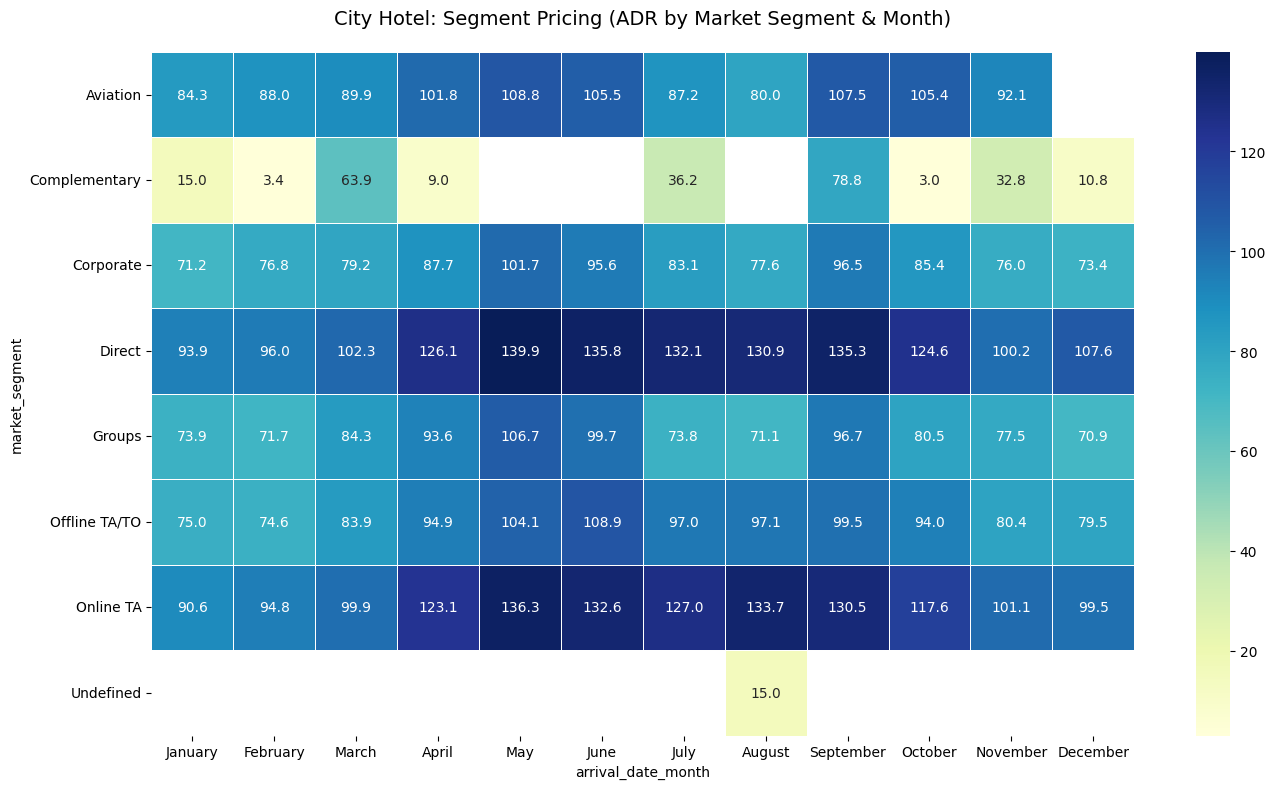

In [ ]:
# =================================================================
# PART 3: EXPLORATORY DATA ANALYSIS (EDA) - CITY HOTEL
# Goal: Analyze pricing drivers to uncover "Revenue DNA"
# =================================================================

# --- 1. Segmentation & Initial Audit ---

# Isolate City Hotel and filter for paying guests (ADR > 0) 
# This ensures our averages reflect actual market revenue
city_hotel = data_backup[(data_backup['hotel'] == 'City Hotel') & (data_backup['adr'] > 0)].copy()

# Benchmark Metrics
city_avg = city_hotel['adr'].mean()
resort_avg = data_backup[(data_backup['hotel'] == 'Resort Hotel') & (data_backup['adr'] > 0)]['adr'].mean()

print(f"--- Benchmark Metrics (Paying Guests Only) ---")
print(f"City Hotel Avg ADR:   ${city_avg:.2f}")
print(f"Resort Hotel Avg ADR: ${resort_avg:.2f}\n")

# Chronological order for consistent plotting
month_order = [
    'January', 'February', 'March', 'April', 'May', 'June', 
    'July', 'August', 'September', 'October', 'November', 'December'
]

# --- 2. Heatmap A: Seasonality & Growth (Year vs Month) ---

city_pivot_year = city_hotel.pivot_table(
    index='arrival_date_year', 
    columns='arrival_date_month', 
    values='adr', 
    aggfunc='mean'
).reindex(columns=month_order)

plt.figure(figsize=(14, 6))
sns.heatmap(city_pivot_year, cmap='YlGnBu', annot=True, fmt=".1f", linewidths=.5)
plt.title('City Hotel: Yield Growth (Average ADR by Year/Month)', fontsize=14, pad=20)
plt.tight_layout()
plt.show()

# --- 3. Heatmap B: Segment Strategy (Market Segment vs Month) ---

segment_pivot = city_hotel.pivot_table(
    index='market_segment', 
    columns='arrival_date_month', 
    values='adr', 
    aggfunc='mean'
).reindex(columns=month_order)

plt.figure(figsize=(14, 8))
sns.heatmap(segment_pivot, cmap='YlGnBu', annot=True, fmt=".1f", linewidths=.5)
plt.title('City Hotel: Segment Pricing (ADR by Market Segment & Month)', fontsize=14, pad=20)
plt.tight_layout()
plt.show()